In [112]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

import importlib
import utils
from logger import ExperimentLogger

importlib.reload(utils)
argFile = 'parameters.json'
try:
    del args
except NameError:
    pass
args = utils.loadJson(argFile)
if args.LoRA:
    args.method = "LoRA"
elif args.wt:
    args.method = "LoRA_full_rank"
else :
    args.method = "standard"
    

In [113]:
def load_runs_with_constraints(path, args):
    runs = ExperimentLogger.load_group(path)

    def match(meta):
        return (
            meta["L"] == args.L and
            meta["beta"] == args.beta and
            meta["method"] == args.method and
            np.isclose(meta["rho"], args.rho) and
            meta["M"] == args.M and
            meta["K"] == args.K and
            meta["N"] == args.N and
            meta["A_only"] == args.A_only and
            meta["alpha"] == args.alpha
        )

    filtered = [r for r in runs if match(r["metadata"])]

    if len(filtered) == 0:
        print("file is empty !")

    return filtered

def runs_to_dict(runs):
    logs = runs[0]["logs"]

    out = {"metadata": runs[0]["metadata"]}

    # global steps if consistent, otherwise keep per-key
    out["steps"] = {}

    for key, entry in logs.items():
        out["steps"][key] = np.array(entry["steps"])

        values = entry["values"]

        if len(values) == 0:
            continue

        out[key] = np.array(values, dtype=object)

    return out
   
# Load the simulation
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
print(path_to_sim)
training_runs = load_runs_with_constraints(path_to_sim, args)
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)

df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

print(df["metadata"])

/home/theom/continual_learning/results/run_K=2_M=1.npy
{'N': 1003, 'M': 1, 'K': 2, 'rho': 0.5, 'alpha': 100, 'beta': 1, 'L': 1, 'A_only': False, 'method': 'standard'}


/tmp/ipykernel_541823/1393191182.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


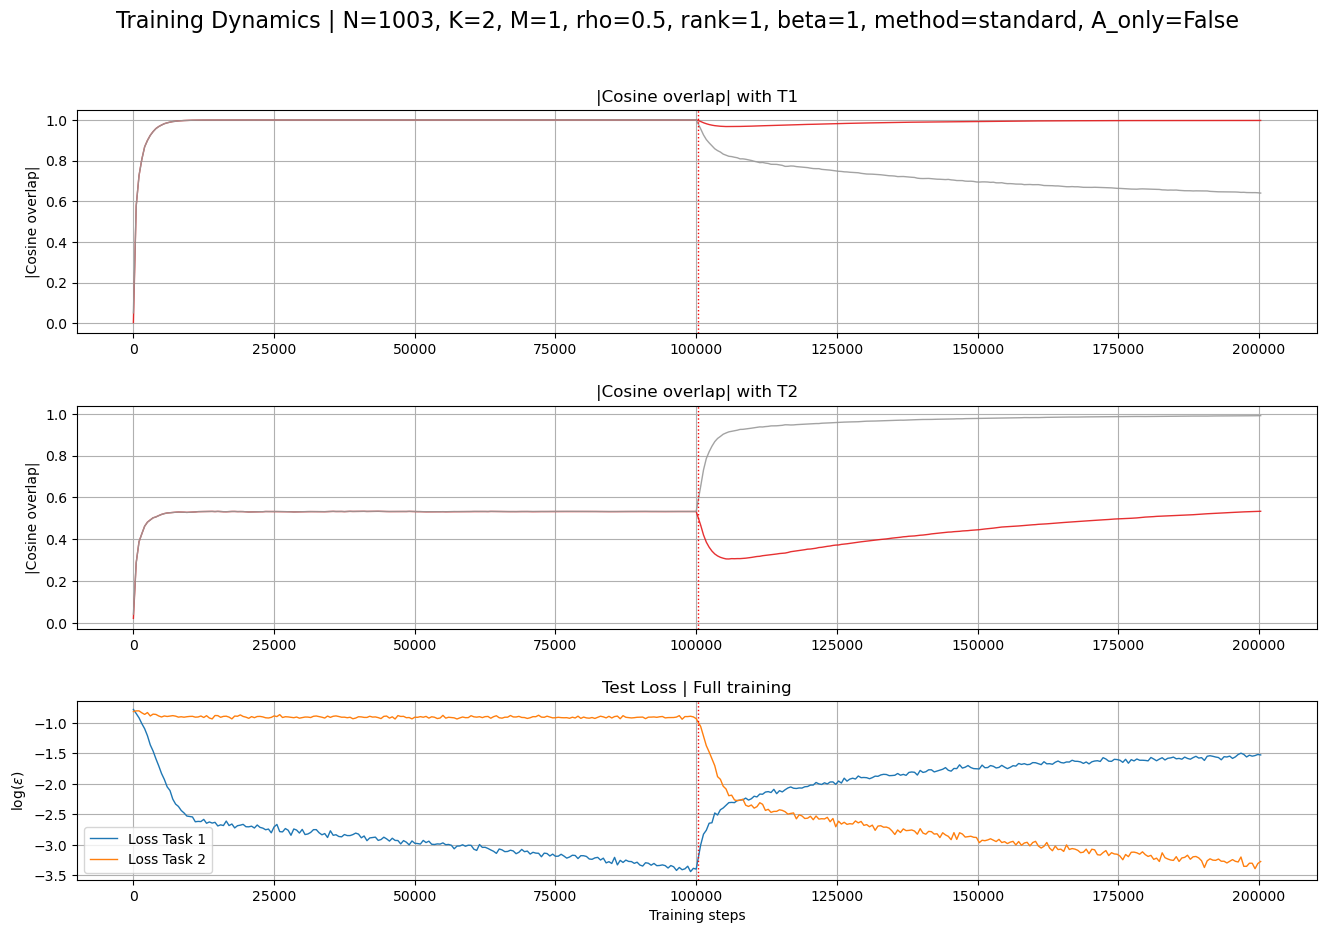

In [114]:
colors = cm.Set1(np.linspace(0, 1, args.K * args.M))

P = df["metadata"]["alpha"] * df["metadata"]["N"]

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Training Dynamics | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}",
    fontsize=16
)

gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.8], hspace=0.35)

ax_t1 = fig.add_subplot(gs[0, 0])

t1_series = np.array(df["overlap_t1"], dtype=object)
t1_steps = np.array(df["steps"]["overlap_t1"])

for idx, (i, j) in enumerate([(i, j) for i in range(args.K) for j in range(args.M)]):

    values = np.array([mat[i, j] for mat in t1_series])

    ax_t1.plot(
        t1_steps,
        np.abs(values),
        lw=1,
        color=colors[idx],
        alpha=0.9
    )

ax_t1.set_title("|Cosine overlap| with T1")
ax_t1.set_ylabel("|Cosine overlap|")
ax_t1.axvline(x=P, linestyle=":", color="red", lw=1)
ax_t1.grid(True)

ax_t2 = fig.add_subplot(gs[1, 0])

t2_series = np.array(df["overlap_t2"], dtype=object)
t2_steps = np.array(df["steps"]["overlap_t2"])
for idx, (i, j) in enumerate([(i, j) for i in range(args.K) for j in range(args.M)]):

    values = np.array([mat[i, j] for mat in t2_series])

    ax_t2.plot(
        t1_steps,   # or df["steps"]["overlap_t1"] if shared
        np.abs(values),
        lw=1,
        color=colors[idx],
        alpha=0.9
    )


ax_t2.set_title("|Cosine overlap| with T2")
ax_t2.set_ylabel("|Cosine overlap|")
ax_t2.axvline(x=P, linestyle=":", color="red", lw=1)
ax_t2.grid(True)


ax_loss = fig.add_subplot(gs[2, 0])
loss1 = np.asarray(df["test_loss_1"], dtype=np.float64)
loss2 = np.asarray(df["test_loss_2"], dtype=np.float64)
steps_loss = np.array(df["steps"]["test_loss_1"])

ax_loss.plot(
    steps_loss,
    np.log10(loss1),
    lw=1,
    label="Loss Task 1"
)

ax_loss.plot(
    steps_loss,
    np.log10(loss2),
    lw=1,
    label="Loss Task 2"
)

ax_loss.set_title("Test Loss | Full training")
ax_loss.set_xlabel("Training steps")
ax_loss.set_ylabel(r"$\log(\epsilon)$")
ax_loss.axvline(x=P, linestyle=":", color="red", lw=1)
ax_loss.grid(True)
ax_loss.legend()


plt.tight_layout()

#plt.savefig(
#    f"training_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_"
#    f"{args.method}_A_only_{args.A_only}.pdf"
#)

plt.show()

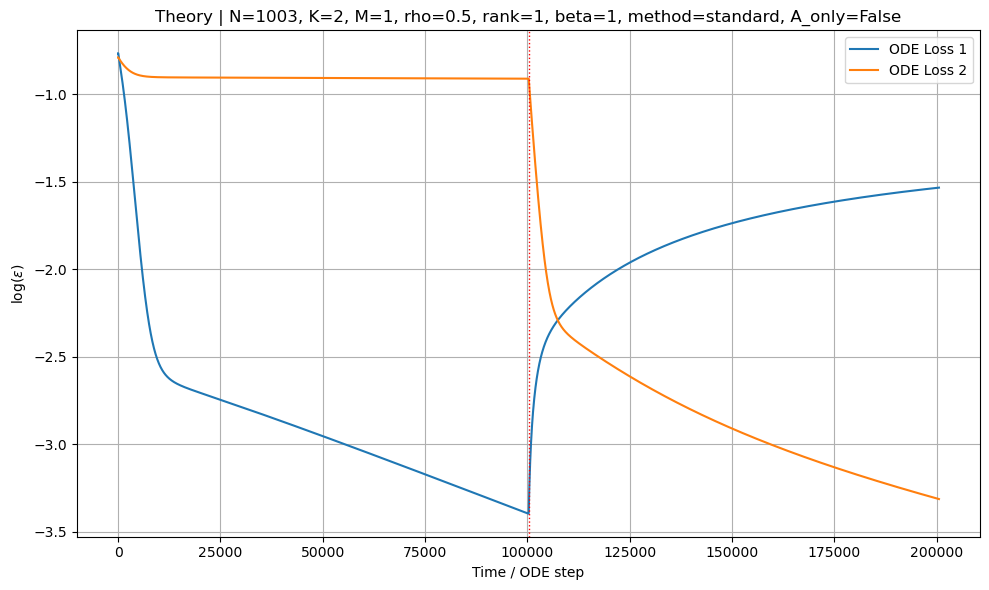

In [115]:
loss1 = np.asarray(df_ODES["test_loss_1"], dtype=np.float64)
loss2 = np.asarray(df_ODES["test_loss_2"], dtype=np.float64)

t_span = np.arange(len(loss1)) * args.integration_step * args.N

plt.figure(figsize=(10, 6))

plt.plot(t_span, np.log10(loss1), label="ODE Loss 1")
plt.plot(t_span, np.log10(loss2), label="ODE Loss 2")

plt.axvline(x=P, linestyle=":", color="red", lw=1.0)

plt.title(
    f"Theory | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}"
)

plt.xlabel("Time / ODE step")
plt.ylabel(r"$\log(\epsilon)$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

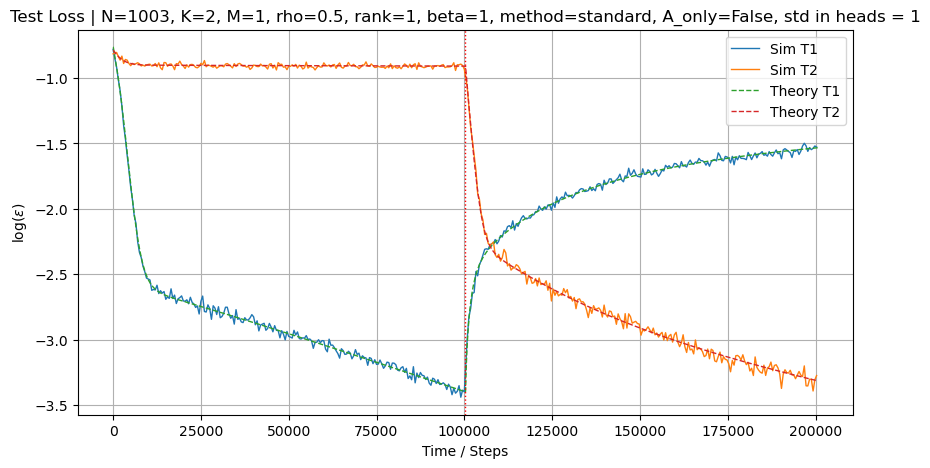

In [116]:
steps_loss = np.array(df["steps"]["test_loss_1"])
t_span = np.arange(len(loss1)) * args.integration_step * args.N

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    steps_loss,
    np.log10(np.asarray(df["test_loss_1"], dtype=np.float64)),
    label="Sim T1",
    lw=1
)

ax.plot(
    steps_loss,
    np.log10(np.asarray(df["test_loss_2"], dtype=np.float64)),
    label="Sim T2",
    lw=1
)

ax.plot(
    t_span,
    np.log10(np.asarray(df_ODES["test_loss_1"], dtype=np.float64)),
    "--",
    label="Theory T1",
    lw=1
)

ax.plot(
    t_span,
    np.log10(np.asarray(df_ODES["test_loss_2"], dtype=np.float64)),
    "--",
    label="Theory T2",
    lw=1
)

P_time = args.N * args.alpha   

ax.axvline(x=P_time, linestyle=":", color="red", lw=1)

ax.set_title(
    f"Test Loss | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}"
    f", std in heads = 1"
)
ax.set_xlabel("Time / Steps")
ax.set_ylabel(r"$\log(\epsilon)$")
ax.grid(True)
ax.legend()

#plt.tight_layout()
plt.savefig(
    f"th_sim_N_{args.N}_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_"
    f"{args.method}_A_only_{args.A_only}.pdf"
)
plt.show()

In [117]:
def plot_overlaps(
    df,
    df_ODES,
    overlap,
    args,
    task=None,
    absval=True,
    log=None
):

    sim_steps = np.array(df["steps"][overlap])
    ode_steps = np.array(df_ODES["steps"][overlap])
    ode_steps = ode_steps * args.integration_step * args.N


    sim_values = np.asarray(df[overlap], dtype=object)
    ode_values = np.asarray(df_ODES[overlap], dtype=object)

    P = args.alpha * args.N

    if task == 1:

        sim_mask = sim_steps <= P
        ode_mask = ode_steps <= P

    elif task == 2:

        sim_mask = sim_steps >= P
        ode_mask = ode_steps >= P

    else:

        sim_mask = np.ones_like(sim_steps, dtype=bool)
        ode_mask = np.ones_like(ode_steps, dtype=bool)

    first = sim_values[0]

    #Scalar
    if np.isscalar(first):

        plt.figure(figsize=(9, 5))

        vals_sim = np.asarray(sim_values, dtype=np.float64)
        vals_ode = np.asarray(ode_values, dtype=np.float64)

        if absval:
            vals_sim = np.abs(vals_sim)
            vals_ode = np.abs(vals_ode)

        plt.plot(
            sim_steps[sim_mask],
            vals_sim[sim_mask] if log==None else np.log10(vals_sim[sim_mask]),
            lw=1.5,
            label="Simulation",
        )

        plt.plot(
            ode_steps[ode_mask],
            vals_ode[ode_mask] if log==None else np.log10(vals_ode[ode_mask]),
            "--",
            lw=1.5,
            label="Theory",
        )

    else:

        shape = np.array(first).shape

        #Vector
        if len(shape) == 1:

            dim = shape[0]

            colors = cm.Set1(np.linspace(0, 1, dim))

            plt.figure(figsize=(10, 6))

            for i in range(dim):

                vals_sim = np.array(
                    [vec[i] for vec in sim_values],
                    dtype=np.float64,
                )

                vals_ode = np.array(
                    [vec[i] for vec in ode_values],
                    dtype=np.float64,
                )

                if absval:
                    vals_sim = np.abs(vals_sim)
                    vals_ode = np.abs(vals_ode)

                plt.plot(
                    sim_steps[sim_mask],
                    vals_sim[sim_mask],
                    color=colors[i],
                    lw=1,
                    alpha=0.9,
                    label=f"Sim ({i})"
                )

                plt.plot(
                    ode_steps[ode_mask],
                    vals_ode[ode_mask],
                    "--",
                    color=colors[i],
                    lw=1,
                    alpha=0.9,
                    label=f"ODE ({i})"
                )
        
        #Matrix
        elif len(shape) == 2:

            K, M = shape

            colors = cm.Set1(np.linspace(0, 1, K * M))

            plt.figure(figsize=(10, 6))

            for idx, (i, j) in enumerate(
                [(i, j) for i in range(K) for j in range(M)]
            ):

                vals_sim = np.array(
                    [mat[i, j] for mat in sim_values],
                    dtype=np.float64,
                )

                vals_ode = np.array(
                    [mat[i, j] for mat in ode_values],
                    dtype=np.float64,
                )

                if absval:
                    vals_sim = np.abs(vals_sim)
                    vals_ode = np.abs(vals_ode)

                plt.plot(
                    sim_steps[sim_mask],
                    vals_sim[sim_mask],
                    color=colors[idx],
                    lw=1,
                    alpha=0.9,
                    label=f"Sim ({i},{j})"
                )

                plt.plot(
                    ode_steps[ode_mask],
                    vals_ode[ode_mask],
                    "--",
                    color=colors[idx],
                    lw=1,
                    alpha=0.9,
                    label=f"ODE ({i},{j})"
                )

        else:

            raise ValueError(
                f"{overlap} has unsupported shape {shape}"
            )

    plt.axvline(
        x=P,
        linestyle=":",
        color="red",
        lw=1,
    )

    plt.title(
        f"{overlap} | "
        f"N={args.N}, K={args.K}, M={args.M}, "
        f"rho={args.rho}, rank={args.L}, "
        f"beta={args.beta}, method={args.method}, "
        f"A_only={args.A_only}"
        f", std 1"
    )
    plt.xlabel("Training steps")
    plt.ylabel(overlap)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

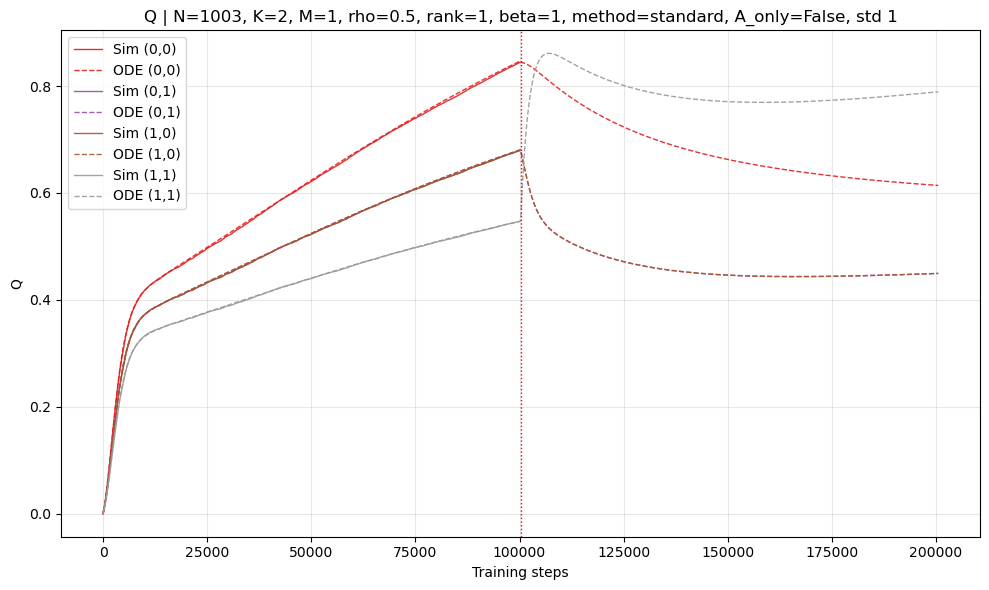

In [118]:
plot_overlaps(
    df,
    df_ODES,
    "Q",
    args,
    task=None,
    absval=True,
)

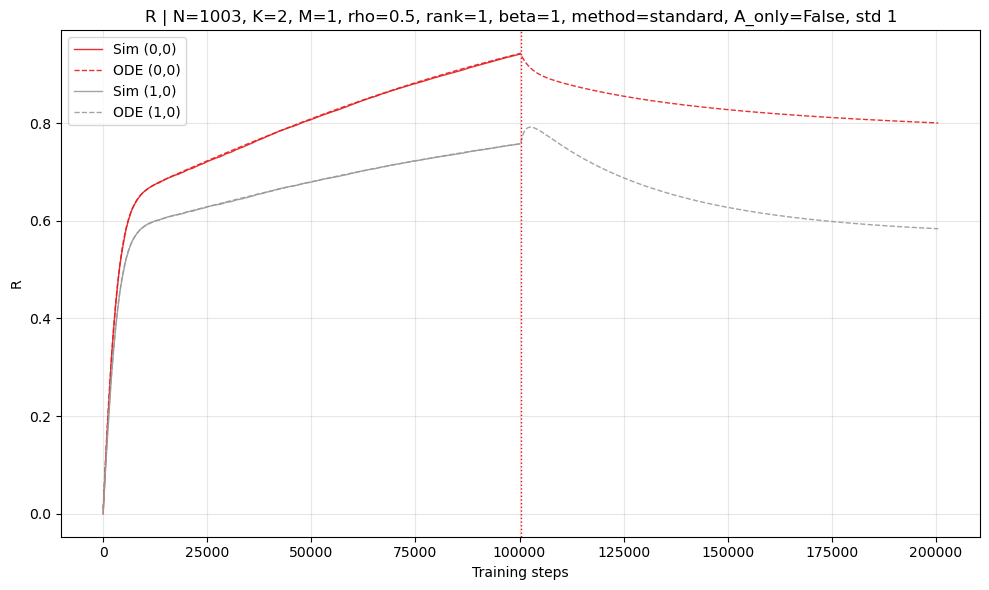

In [119]:
plot_overlaps(
    df,
    df_ODES,
    "R",
    args,
    task=None,
    absval=True,
)

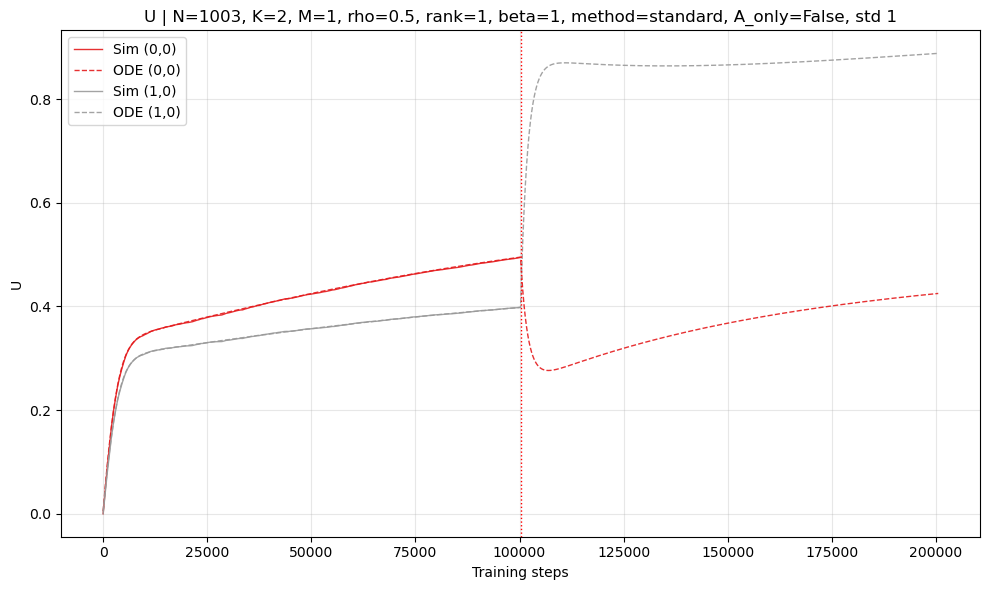

In [120]:
plot_overlaps(
    df,
    df_ODES,
    "U",
    args,
    task=None,
    absval=True,
)

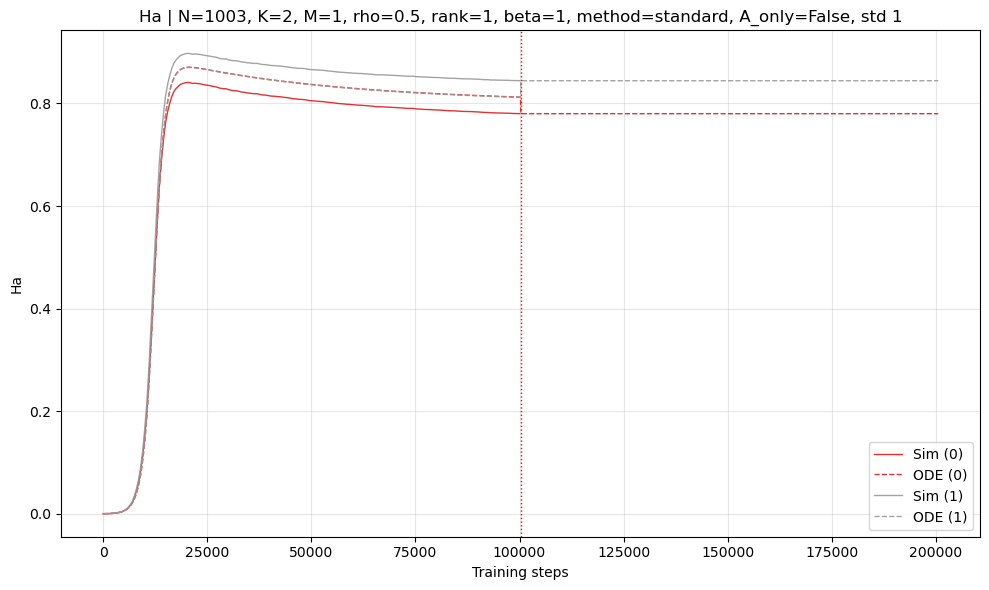

In [109]:
plot_overlaps(
    df,
    df_ODES,
    "Ha",
    args,
    task=None,
    absval=True,
)

In [110]:
plot_overlaps(
    df,
    df_ODES,
    "D",
    args,
    task=2,
    absval=True,
)

KeyError: 'D'

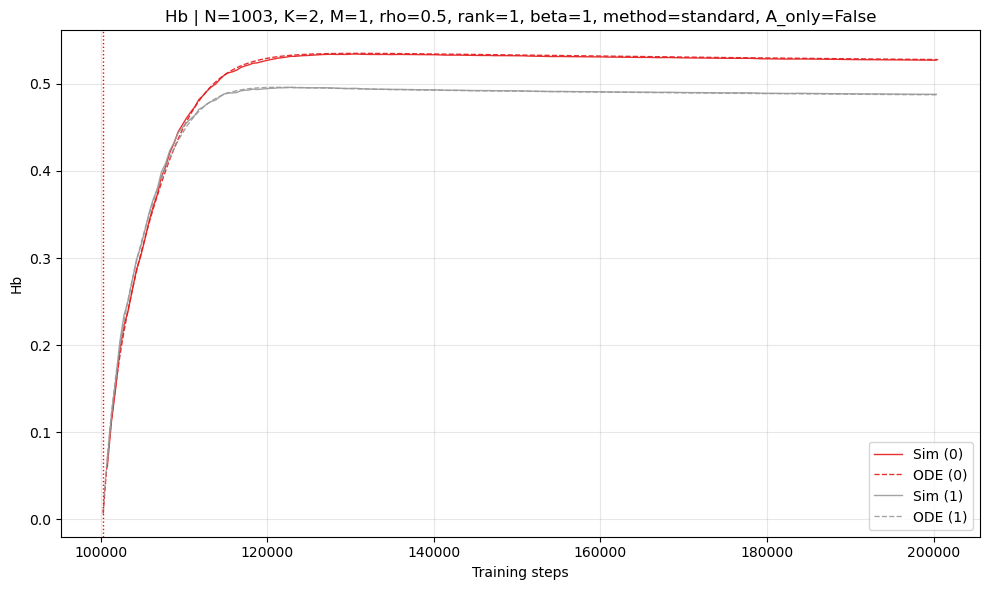

In [35]:
plot_overlaps(
    df,
    df_ODES,
    "Hb",
    args,
    task=2,
    absval=True,
)

In [36]:
plot_overlaps(
    df,
    df_ODES,
    "G",
    args,
    task=2,
    absval=True,
)

KeyError: 'G'

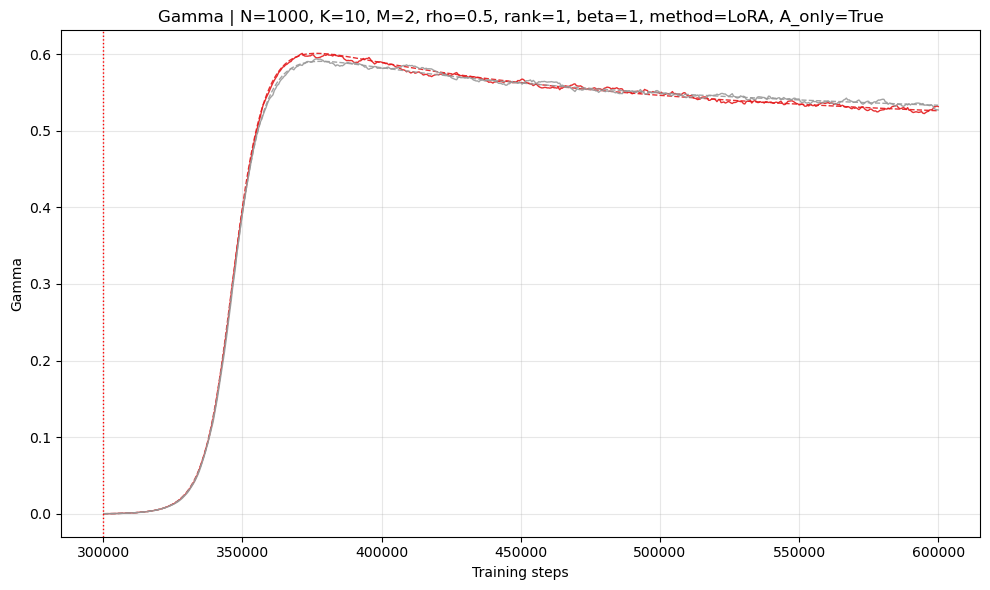

In [147]:
plot_overlaps(
    df,
    df_ODES,
    "Gamma",
    args,
    task=2,
    absval=True,
)

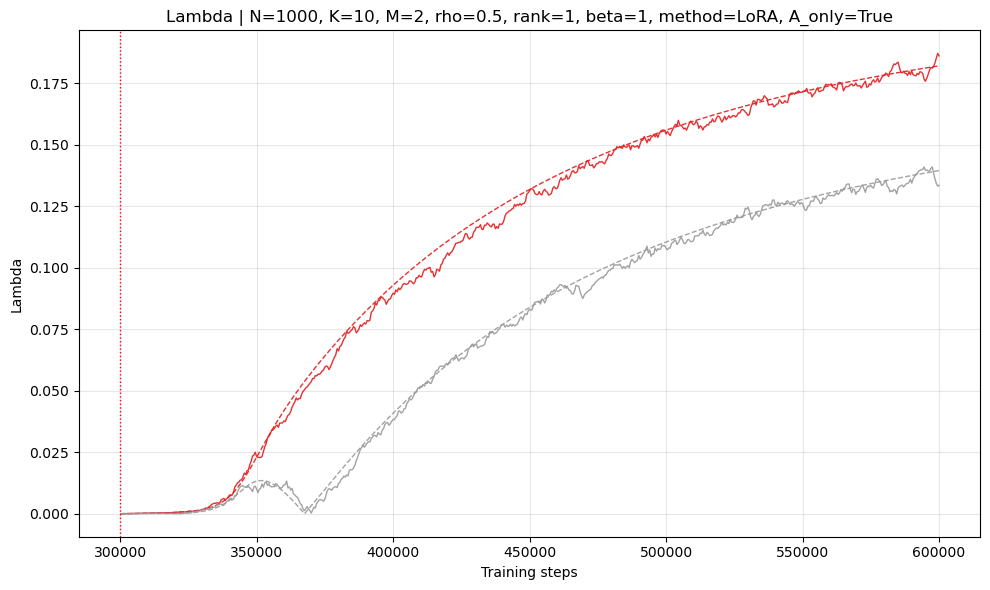

In [148]:
plot_overlaps(
    df,
    df_ODES,
    "Lambda",
    args,
    task=2,
    absval=True,
)

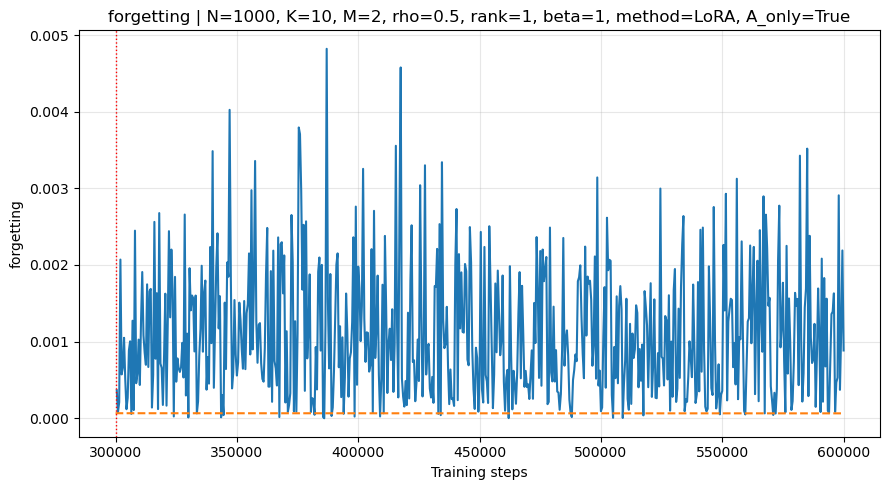

In [149]:
plot_overlaps(
    df,
    df_ODES,
    "forgetting",
    args,
    task=2,
    absval=True,
)

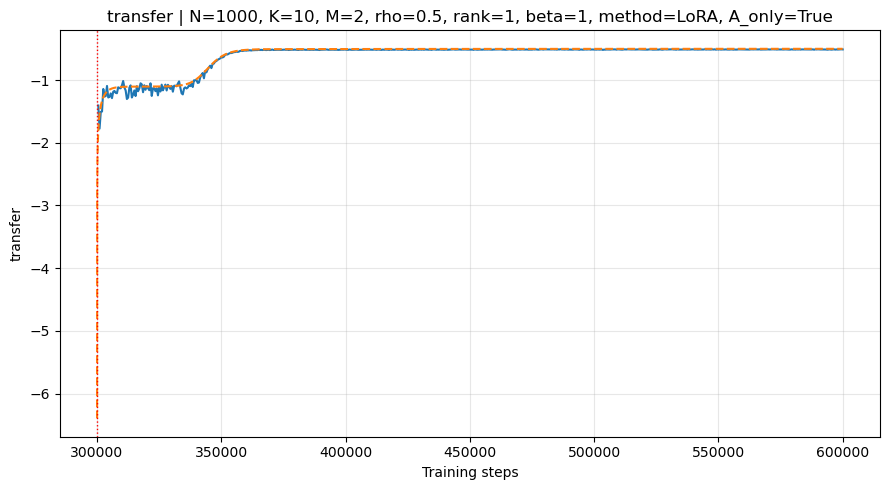

In [150]:
plot_overlaps(
    df,
    df_ODES,
    "transfer",
    args,
    task=2,
    absval=True,
    log=True
)

In [ ]:
def plot_curves(
    ax,
    df,
    x_axis=None,
    label_suffix="",
    color=None,
    ODES=False,
    integration_step=None,
    alpha_param=None,
    N=None,
    lw=1,
):
    if ODES == False :
        x_axis = np.array(df["steps"]["test_loss_1"])
        alpha = 1.0
        lw=1.5
        marker = None
        markevery= 10
    else :
        x_axis = np.arange(len(loss1)) * args.integration_step * args.N
        lw = 2.5
        alpha = 0.8
        marker = "o"
        markevery = 75

    ax.plot(
        x_axis,
        np.log10(np.asarray(df["test_loss_1"], dtype=np.float64)),
        linewidth=lw,
        linestyle="-",
        marker=marker,
        markevery=markevery,
        markersize=4,
        color=color,
        alpha=alpha,
        label=f"Task 1 {label_suffix}",
    )

    ax.plot(
        x_axis,
        np.log10(np.asarray(df["test_loss_2"], dtype=np.float64)),
        linewidth=lw,
        linestyle=":",
        marker=marker,
        markevery=markevery,
        markersize=4,
        color=color,
        alpha=alpha,
        label=f"Task 2 {label_suffix}",
    )

colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

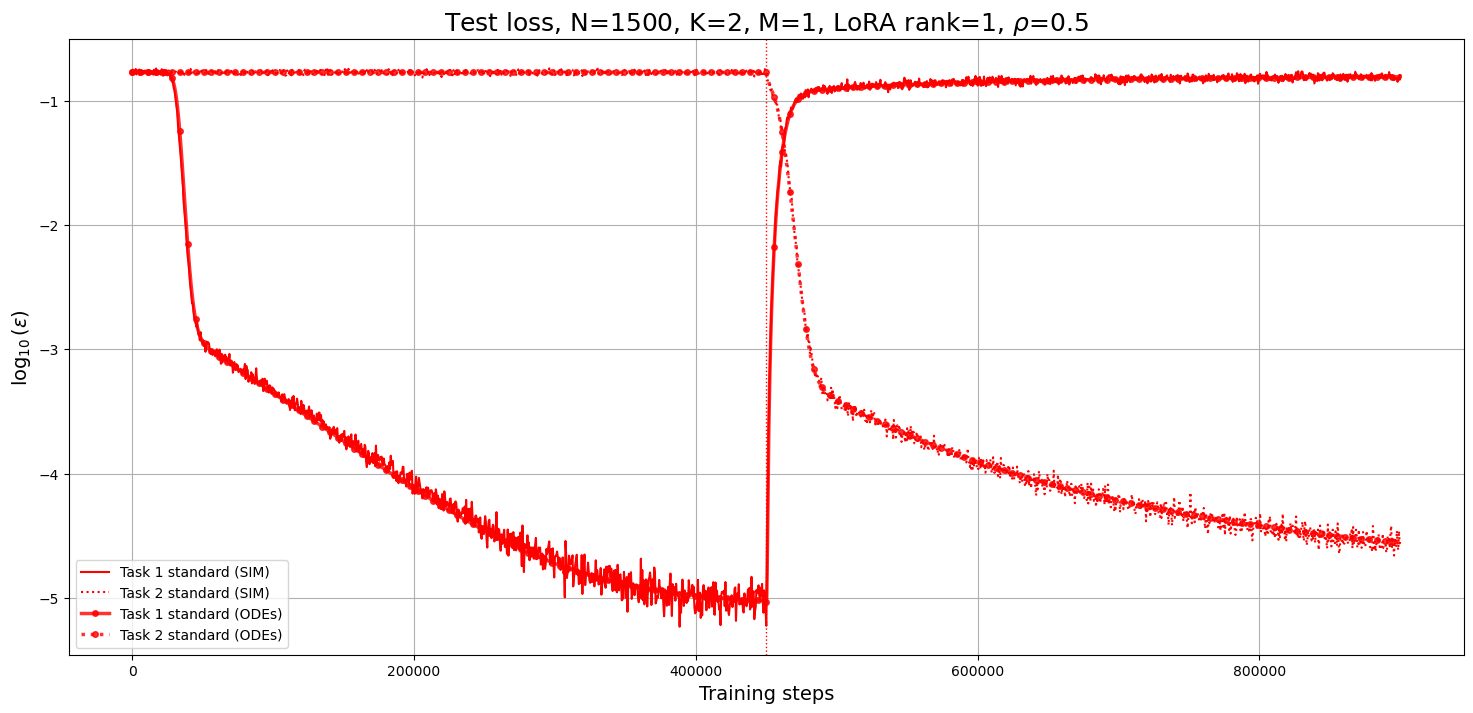

In [ ]:
args.method="standard"
args.A_only = False
path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
if len(training_runs) == 0 or len(ode_runs) == 0:
    raise ValueError("No runs found after filtering constraints.")

df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

P = df["metadata"]["alpha"] * df["metadata"]["N"]

fig, ax = plt.subplots(figsize=(18, 8))

plot_curves(
    ax,
    df,
    label_suffix="standard (SIM)",
    color=colors["standard"],
    ODES=False
)

plot_curves(
    ax,
    df_ODES,
    label_suffix="standard (ODEs)",
    color=colors["standard"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)

ax.set_title(
    rf"Test loss, N={args.N}, K={args.K}, M={args.M}, "
    rf"LoRA rank={args.L}, $\rho$={args.rho}",
    fontsize=18
)

ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\epsilon)$", fontsize=14)

ax.axvline(x=P, linestyle=":", color="red", lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")

fig.savefig(
    os.path.join(args.path_to_res_folder, "1-test_loss_standard.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

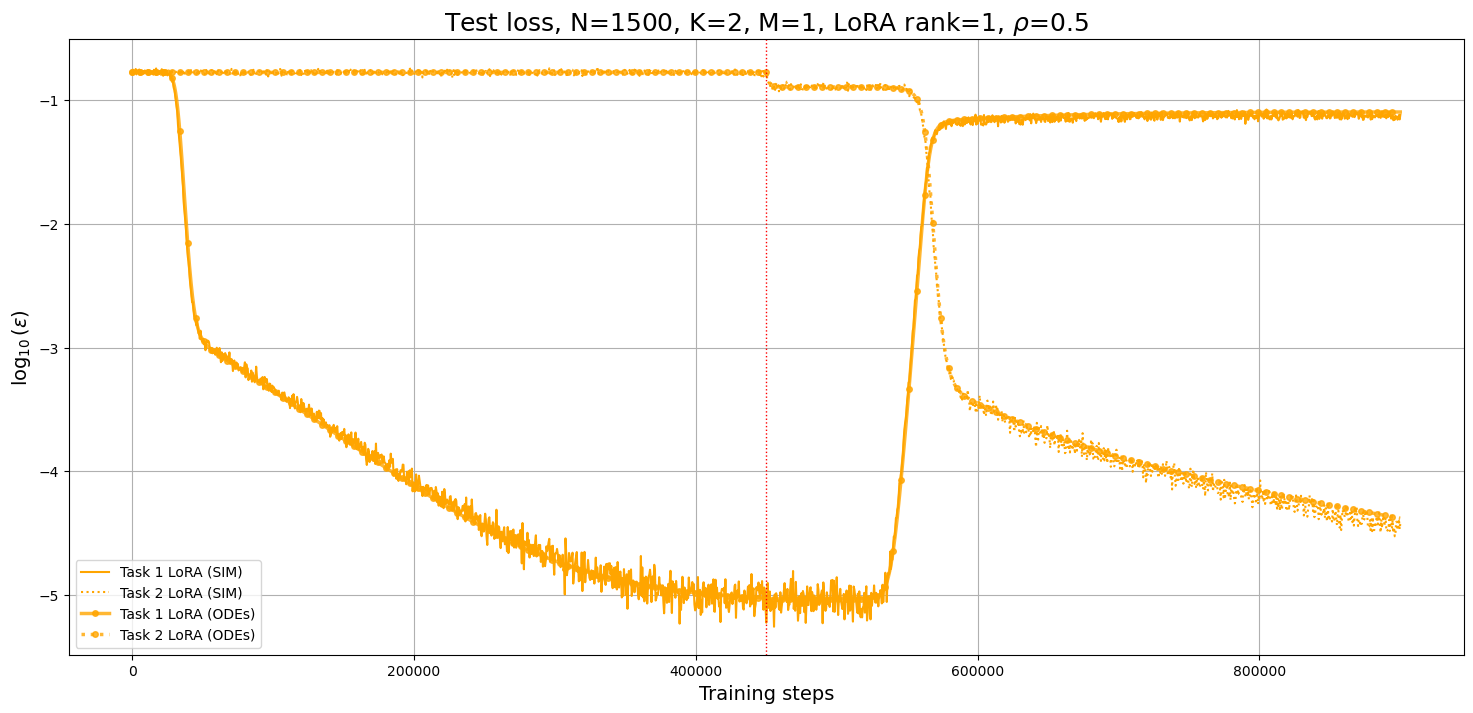

In [ ]:
args.method="LoRA"
args.A_only = False
path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
if len(training_runs) == 0 or len(ode_runs) == 0:
    raise ValueError("No runs found after filtering constraints.")

df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

P = df["metadata"]["alpha"] * df["metadata"]["N"]

fig, ax = plt.subplots(figsize=(18, 8))

plot_curves(
    ax,
    df,
    label_suffix="LoRA (SIM)",
    color=colors["LoRA"],
    ODES=False
)

plot_curves(
    ax,
    df_ODES,
    label_suffix="LoRA (ODEs)",
    color=colors["LoRA"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)

ax.set_title(
    rf"Test loss, N={args.N}, K={args.K}, M={args.M}, "
    rf"LoRA rank={args.L}, $\rho$={args.rho}",
    fontsize=18
)

ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\epsilon)$", fontsize=14)

ax.axvline(x=P, linestyle=":", color="red", lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")

fig.savefig(
    os.path.join(args.path_to_res_folder, "2-test_loss_LoRA.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

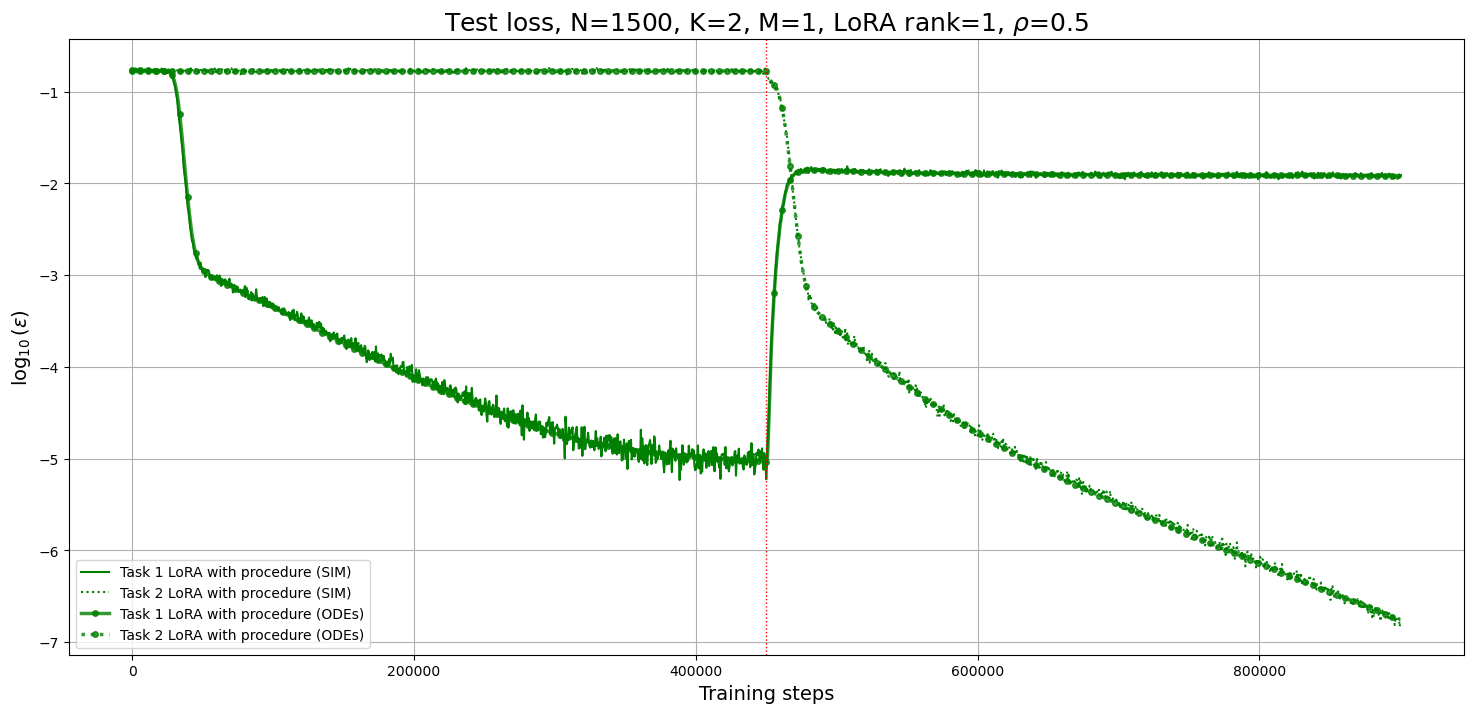

In [ ]:
args.method="LoRA"
args.A_only = True
path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
if len(training_runs) == 0 or len(ode_runs) == 0:
    raise ValueError("No runs found after filtering constraints.")

df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

P = df["metadata"]["alpha"] * df["metadata"]["N"]

fig, ax = plt.subplots(figsize=(18, 8))

plot_curves(
    ax,
    df,
    label_suffix="LoRA with procedure (SIM)",
    color=colors["LoRA_A_only"],
    ODES=False
)

plot_curves(
    ax,
    df_ODES,
    label_suffix="LoRA with procedure (ODEs)",
    color=colors["LoRA_A_only"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)

ax.set_title(
    rf"Test loss, N={args.N}, K={args.K}, M={args.M}, "
    rf"LoRA rank={args.L}, $\rho$={args.rho}",
    fontsize=18
)

ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\epsilon)$", fontsize=14)

ax.axvline(x=P, linestyle=":", color="red", lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")

fig.savefig(
    os.path.join(args.path_to_res_folder, "3-test_loss_LoRA_procedure.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

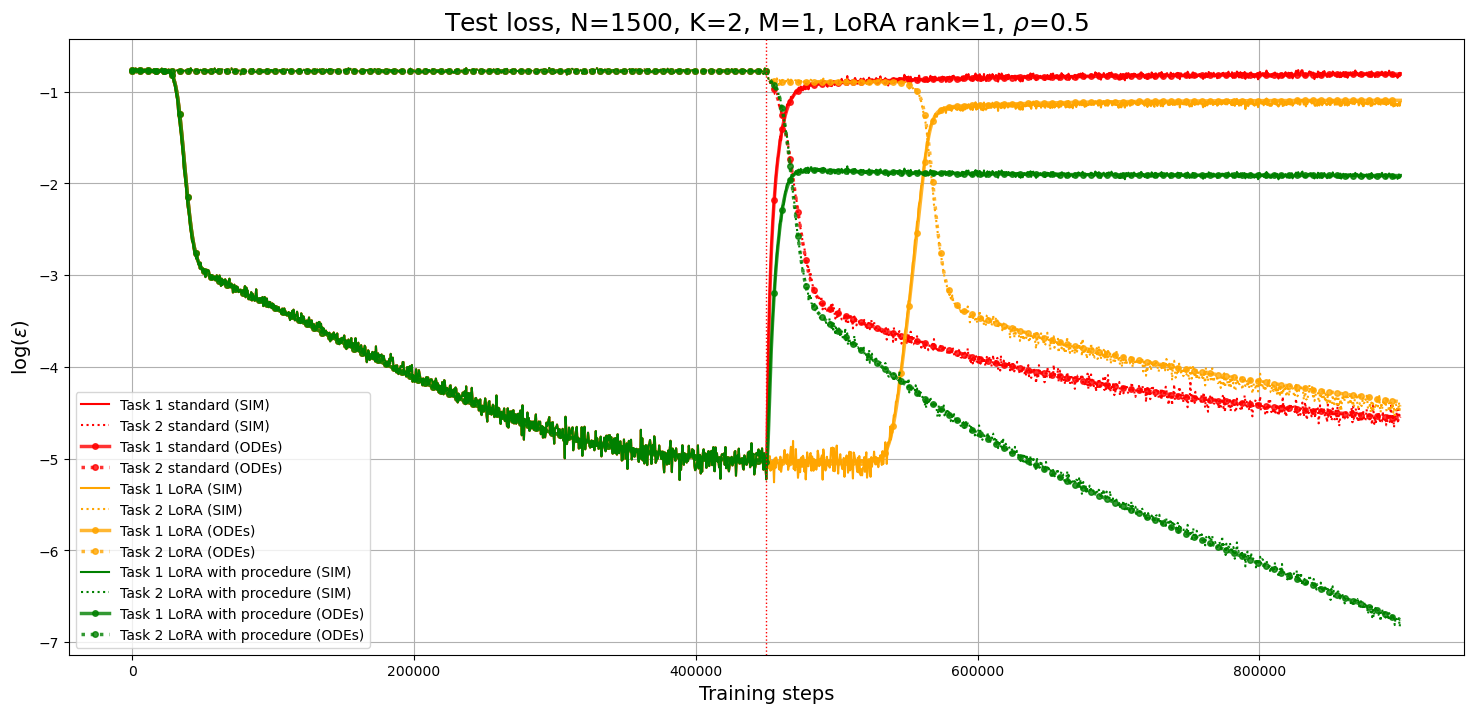

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

args.method="standard"
args.A_only = False
training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

plot_curves(
    ax,
    df,
    label_suffix="standard (SIM)",
    color=colors["standard"],
    ODES=False,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)
plot_curves(
    ax,
    df_ODES,
    label_suffix="standard (ODEs)",
    color=colors["standard"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)

args.method="LoRA"
args.A_only = False
training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

plot_curves(
    ax,
    df,
    label_suffix="LoRA (SIM)",
    color=colors["LoRA"],
    ODES=False,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)
plot_curves(
    ax,
    df_ODES,
    label_suffix="LoRA (ODEs)",
    color=colors["LoRA"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)

args.method="LoRA"
args.A_only = True
training_runs = load_runs_with_constraints(path_to_sim, args)
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)
df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)

plot_curves(
    ax,
    df,
    label_suffix="LoRA with procedure (SIM)",
    color=colors["LoRA_A_only"],
    ODES=False,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)
plot_curves(
    ax,
    df_ODES,
    label_suffix="LoRA with procedure (ODEs)",
    color=colors["LoRA_A_only"],
    ODES=True,
    integration_step=args.integration_step,
    alpha_param=args.alpha,
    N=args.N
)


ax.set_title( rf"Test loss, N={args.N}, K={args.K}, M={args.M}, LoRA rank={args.L}, $\rho$={args.rho}", fontsize=18)
ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log(\epsilon)$", fontsize=14)
ax.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax.grid(True)
#ax.set_ylim(ymin, ymax)
ax.legend(loc="lower left")
fig.savefig(os.path.join(args.path_to_res_folder, "4bis-test_loss_LGS+LoRA.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np


def extract_metric_at_switch(
    run,
    metric_key,
    P,
    ODES=False,
    integration_step=None,
):

    logs = run["logs"]
    
    if metric_key not in logs:
        return None

    values = np.array(logs[metric_key]["values"], dtype=float)

    if len(values) == 0:
        return None

    if not ODES:
        steps = np.array(logs[metric_key]["steps"])
        idx = np.argmin(np.abs(steps - P))
        return float(values[idx])

    else:
        N = int(run["metadata"]["N"])
        x_axis = (np.arange(len(values))* integration_step*N)
        idx = np.argmin(np.abs(x_axis - P))
        return float(values[idx])


def extract_final_metric(run, metric_key):

    logs = run["logs"]

    if metric_key not in logs:
        return None

    values = logs[metric_key]["values"]

    if len(values) == 0:
        return None

    return float(values[-1])

def compute_metric(
    run,
    metric_type,
    ODES=False,
    integration_step=None,
):

    meta = run["metadata"]

    alpha = float(meta["alpha"])
    N = int(meta["N"])

    P = alpha * N

    switch_loss_1 = extract_metric_at_switch(
    run,
    "test_loss_1",
    P,
    ODES=ODES,
    integration_step=integration_step,
    )

    switch_loss_2 = extract_metric_at_switch(
    run,
    "test_loss_2",
    P,
    ODES=ODES,
    integration_step=integration_step,
    )

    final_loss_1 = extract_final_metric(run, "test_loss_1")
    final_loss_2 = extract_final_metric(run, "test_loss_2")

    if None in [
        switch_loss_1,
        switch_loss_2,
        final_loss_1,
        final_loss_2,
    ]:
        return None

    if metric_type == "forgetting":
        metric_1 = ( np.log10(final_loss_1) - np.log10(switch_loss_1) )
        metric_2 = ( np.log10(final_loss_2) - np.log10(switch_loss_2) )
        
    elif metric_type == "transfer":
        metric_1 = ( np.log10(switch_loss_1) - np.log10(final_loss_1) )
        metric_2 = ( np.log10(switch_loss_2) - np.log10(final_loss_2) )

    else:
        raise ValueError(
            "metric_type must be 'forgetting' or 'transfer'"
        )

    return metric_1, metric_2


def plot_metric_vs_rho(
    ax,
    runs_sim,
    metric_type="forgetting",
    runs_odes=None,
    label="",
    color=None
):

    sim_task_1 = []
    sim_task_2 = []

    for run in runs_sim:

        meta = run["metadata"]
        rho = float(meta["rho"])
        metrics = compute_metric(
        run,
        metric_type,
        ODES=False,
        integration_step=args.integration_step
        )

        if metrics is None:
            continue

        metric_1, metric_2 = metrics

        sim_task_1.append((rho, metric_1))
        sim_task_2.append((rho, metric_2))

    sim_task_1.sort(key=lambda x: x[0])
    sim_task_2.sort(key=lambda x: x[0])

    rhos_1 = np.array([x[0] for x in sim_task_1])
    vals_1 = np.array([x[1] for x in sim_task_1])
    rhos_2 = np.array([x[0] for x in sim_task_2])
    vals_2 = np.array([x[1] for x in sim_task_2])

    if metric_type=="forgetting" :
        ax.plot(
            rhos_1,
            vals_1,
            marker="o",
            markersize=7,
            linewidth=2.5,
            color=color,
            label=f"{label} (SIM)",
        )

    elif metric_type=="transfer":
        ax.plot(
            rhos_2,
            vals_2,
            marker="o",
            markersize=7,
            linewidth=2.5,
            color=color,
            label=f"{label} (SIM)",
        )
    else:
        raise ValueError("metric_type not implemented")

    if runs_odes is not None:

        ode_task_1 = []
        ode_task_2 = []

        for run in runs_odes:

            meta = run["metadata"]

            rho = float(meta["rho"])

            metrics = compute_metric(
            run,
            metric_type,
            ODES=True,
            integration_step=args.integration_step
            )

            if metrics is None:
                continue

            metric_1, metric_2 = metrics

            ode_task_1.append((rho, metric_1))
            ode_task_2.append((rho, metric_2))

        ode_task_1.sort(key=lambda x: x[0])
        ode_task_2.sort(key=lambda x: x[0])

        rhos_1_ode = np.array([x[0] for x in ode_task_1])
        vals_1_ode = np.array([x[1] for x in ode_task_1])

        rhos_2_ode = np.array([x[0] for x in ode_task_2])
        vals_2_ode = np.array([x[1] for x in ode_task_2])

        if metric_type=="forgetting" :
            ax.plot(
                rhos_1_ode,
                vals_1_ode,
                marker="s",
                markersize=7,
                linewidth=2.5,
                linestyle="--",
                color=color,
                label=f"{label} (ODEs)",
            )

        elif metric_type == "transfer":
            ax.plot(
                rhos_2_ode,
                vals_2_ode,
                marker="s",
                markersize=7,
                linewidth=2.5,
                linestyle="--",
                color=color,
                label=f" {label} (ODEs)",
            )
        else :
            raise ValueError("metric type not implemented")

    ax.set_xlabel(r"$\rho$", fontsize=14)

    ax.set_ylabel(
        metric_type.capitalize(),
        fontsize=14,
    )

    ax.set_title(
        f"{metric_type.capitalize()} vs correlation parameter",
        fontsize=16,
    )

    ax.grid(True, alpha=0.3)

    ax.legend(frameon=True, fontsize=12)

    ax.margins(x=0.02)

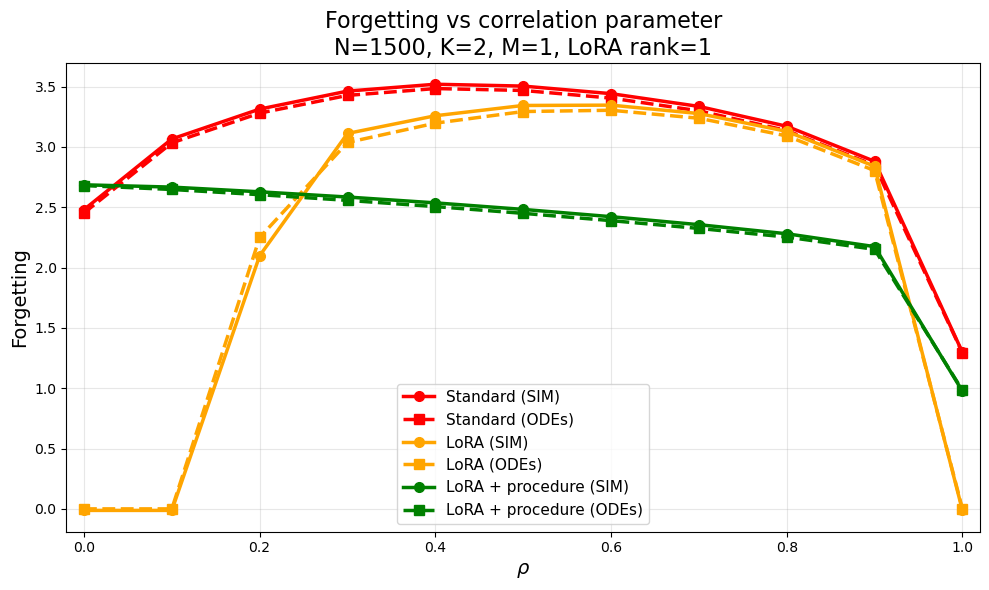

In [36]:
colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

fig, ax = plt.subplots(figsize=(10, 6))


# ============================================================
# STANDARD
# ============================================================

args.method = "standard"
args.A_only = False

sim_runs_standard = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_standard = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]
plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_standard,
    runs_odes=ode_runs_standard,
    metric_type="forgetting",
    label="Standard",
    color=colors["standard"]
)


# ============================================================
# LoRA
# ============================================================

args.method = "LoRA"
args.A_only = False

sim_runs_lora = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_lora = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_lora,
    runs_odes=ode_runs_lora,
    metric_type="forgetting",
    label="LoRA",
    color=colors["LoRA"]
)


# ============================================================
# LoRA + procedure
# ============================================================

args.method = "LoRA"
args.A_only = True

sim_runs_proc = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_proc = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_proc,
    runs_odes=ode_runs_proc,
    metric_type="forgetting",
    label="LoRA + procedure",
    color=colors["LoRA_A_only"]
)


# ============================================================
# FIGURE SETTINGS
# ============================================================

ax.set_xlabel(r"$\rho$", fontsize=14)

ax.set_ylabel(
    "Forgetting",
    fontsize=14,
)

ax.set_title(
    f"Forgetting vs correlation parameter\n"
    f"N={args.N}, K={args.K}, M={args.M}, "
    f"LoRA rank={args.L}",
    fontsize=16,
)

ax.grid(True, alpha=0.3)

ax.legend(frameon=True, fontsize=11)

plt.tight_layout()

fig.savefig(
    os.path.join(
        args.path_to_res_folder,
        "5-forgetting.pdf"
    ),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

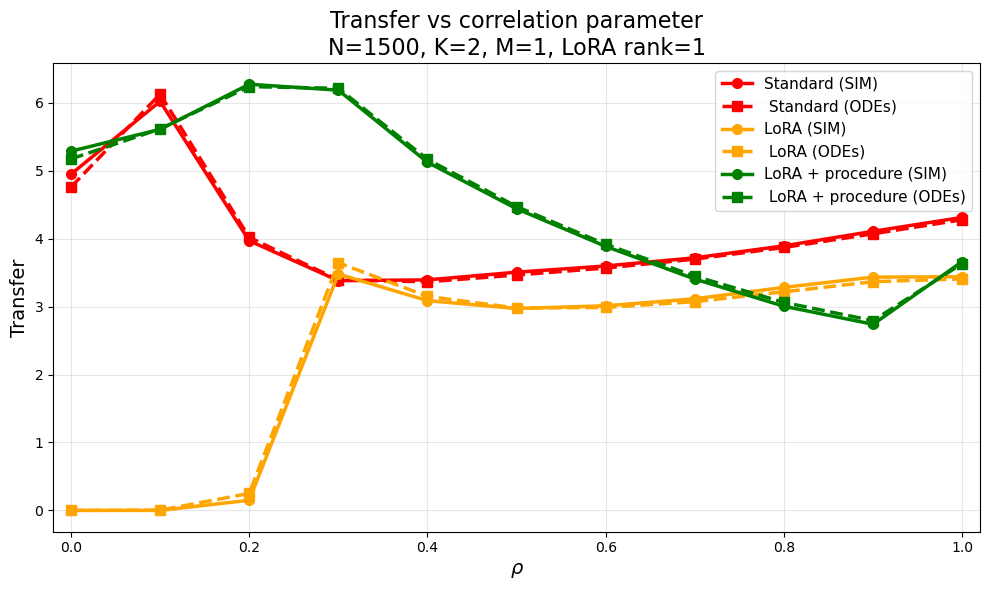

In [37]:
colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

fig, ax = plt.subplots(figsize=(10, 6))


# ============================================================
# STANDARD
# ============================================================

args.method = "standard"
args.A_only = False

sim_runs_standard = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_standard = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]
plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_standard,
    runs_odes=ode_runs_standard,
    metric_type="transfer",
    label="Standard",
    color=colors["standard"]
)


# ============================================================
# LoRA
# ============================================================

args.method = "LoRA"
args.A_only = False

sim_runs_lora = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_lora = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_lora,
    runs_odes=ode_runs_lora,
    metric_type="transfer",
    label="LoRA",
    color=colors["LoRA"]
)


# ============================================================
# LoRA + procedure
# ============================================================

args.method = "LoRA"
args.A_only = True

sim_runs_proc = [
    r for r in all_sim_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

ode_runs_proc = [
    r for r in all_ode_runs
    if (
        r["metadata"]["method"] == args.method
        and bool(r["metadata"]["A_only"]) == args.A_only
        and r["metadata"]["K"] == args.K
        and r["metadata"]["M"] == args.M
        and r["metadata"]["N"] == args.N
        and r["metadata"]["L"] == args.L
    )
]

plot_metric_vs_rho(
    ax,
    runs_sim=sim_runs_proc,
    runs_odes=ode_runs_proc,
    metric_type="transfer",
    label="LoRA + procedure",
    color=colors["LoRA_A_only"]
)


# ============================================================
# FIGURE SETTINGS
# ============================================================

ax.set_xlabel(r"$\rho$", fontsize=14)

ax.set_ylabel(
    "Transfer",
    fontsize=14,
)

ax.set_title(
    f"Transfer vs correlation parameter\n"
    f"N={args.N}, K={args.K}, M={args.M}, "
    f"LoRA rank={args.L}",
    fontsize=16,
)

ax.grid(True, alpha=0.3)

ax.legend(frameon=True, fontsize=11)

plt.tight_layout()

fig.savefig(
    os.path.join(
        args.path_to_res_folder,
        "6-transfer.pdf"
    ),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [111]:
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

ExperimentLogger.delete_runs(
    path_to_sim,
    lambda meta:
        meta["method"] == "standard" and
        meta["A_only"] == False and
        np.isclose(meta["rho"], 0.5) and
        np.isclose(meta["alpha"], 100)
)
ExperimentLogger.delete_runs(
    path_to_sim_ODEs,
    lambda meta:
        meta["method"] == "standard" and
        meta["A_only"] == False and
        np.isclose(meta["rho"], 0.5) and
        np.isclose(meta["alpha"], 100)
)

Deleted 1 runs.
Deleted 1 runs.
